# Assessing Case Eligibility for Right Turn Analysis

In [1]:
from case_functions import *


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



Load in u and v data

In [2]:
#dates = ['20220523', '20220524', '20220531','20230524', '20230527', '20230609','20230611', '20230612', '20240502', '20240504', '20240519', '20240523', '20240602']

# dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
#         '20230611', '20230612', '20230613','20230615', '20240502', '20240504', '20240506',
#           '20240523', '20240528']
# dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
#         '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240502', '20240504', '20240506', '20240519'
#           '20240523', '20240528', '20240602']
# GETTING RID OF 20240504 AND 20240502 BECAUSE IT WAS TOO HIGH (TOO LOW), STRANGE OUTLIER AND 20240528
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240506', '20240519'
          '20240523', '20240602'] #'20240528',
kas = ['ka1', 'ka2']
heights = np.arange(50, 2010, 10)

In [3]:
weights = [0.05, 0.2, 0.5, 0.2, 0.05]

In [98]:
very_dark_red = "#4B0000"

In [4]:
df_all_new = pd.DataFrame()
#for ka in kas:
for d in dates:
    for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_*_all.csv'):
        try:
            not_comp_file_name_new = file
            print(not_comp_file_name_new)
            df_new = pd.read_csv(not_comp_file_name_new)
            df_new['Date'] = d
            print(np.shape(df_new))
            if df_new['Time From Tor (min)'].eq('nontor').any():
                df_new['Tor or Nontor'] = 'nontor'
            else:
                df_new['Tor or Nontor'] = 'tor'
                
            df_all_new = pd.concat([df_all_new, df_new], ignore_index=True)
        except FileNotFoundError:
            print(f"File not found: {not_comp_file_name_new}")
            continue

case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka1_all.csv
(120, 202)
case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka2_all.csv
(20, 202)
case_dfs/new/new_secondtrip/nontornadic/20220524_uv_ka1_all.csv
(100, 202)
case_dfs/new/new_secondtrip/tornadic/20230524_uv_ka2_all.csv
(284, 202)
case_dfs/new/new_secondtrip/tornadic/20230527_uv_ka1_all.csv
(506, 202)
case_dfs/new/new_secondtrip/nontornadic/20230611_uv_ka1_all.csv
(388, 202)
case_dfs/new/new_secondtrip/nontornadic/20230612_uv_ka2_all.csv
(198, 202)
case_dfs/new/new_secondtrip/nontornadic/20230613_uv_ka1_all.csv
(20, 202)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka1_all.csv
(572, 202)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka2_all.csv
(352, 202)
case_dfs/new/new_secondtrip/nontornadic/20240427_uv_ka1_all.csv
(314, 202)
case_dfs/new/new_secondtrip/nontornadic/20240501_uv_ka1_all.csv
(850, 202)
case_dfs/new/new_secondtrip/tornadic/20240602_uv_ka1_all.csv
(262, 202)


In [5]:
# Get the list of column names greater than 100
#cols_above_100 = [str(i) for i in range(101, 199)]  # up to 198
cols_above_100 = [col for col in df_all_new.columns if col.isdigit() and 100 <= int(col) <= 198]
# Set those columns to NaN for the target date
df_all_new.loc[df_all_new['Date'] == '20240501', cols_above_100] = np.nan
#df_all_new.loc[df_all_new['Date'] == '20240528', cols_above_100] = np.nan

In [6]:
def time_from_tor(ka_df, storm_event_data, event_type, tornado_location, timezone, daylight_savings):
    '''
    This function uses .csv from NOAA's Storm Events Database to compare 
    the times VADs were taken with when the tornado was reported.

    ka_df = dataframe you want the tor ids to be added to
    date = date the data from the storm event database was recorded (MMDDYYYY)
    event_type = is typically 'Tornado' but for posterity left it as a variable
    storm_event_data = csv from the storm event database
    tornado_location = str of the desired location name IN ALL CAPS
    timezone = str of timezone in format US/timezone (Central, Mountain, etc)
    daylight_savings = False, the database reports in standard time, even during daylight savings
    '''
    tor_begin_time = []
    tor_end_time = []
    tor_begin_date = []
    tor_end_date = []
    vads_tor_time = []
    vads_tor_nontor = []
    tor_id = storm_event_data.EVENT_TYPE == event_type
    tor_loc = storm_event_data.BEGIN_LOCATION.isin(tornado_location)
    
    for i in range(len(tor_id)):
        if tor_id[i] == True and tor_loc[i] == True:
            print(storm_event_data.BEGIN_TIME[i], storm_event_data.BEGIN_LOCATION[i])
            tor_begin_time.append(storm_event_data.BEGIN_TIME[i])
            tor_end_time.append(storm_event_data.END_TIME[i])
            tor_begin_date.append(storm_event_data.BEGIN_DATE[i])
            tor_end_date.append(storm_event_data.END_DATE[i])
        else:
            continue
            
    tor_begin_time_array = np.array(tor_begin_time)
    tor_end_time_array = np.array(tor_end_time)

    tor_start_dt_list = []
    tor_end_dt_list = []
    
    for i in range(len(tor_begin_time_array)):
        tor_start = tor_begin_date[i] + str(f' {tor_begin_time_array[i]}')
        tor_start_dt = datetime.strptime(tor_start, '%m/%d/%Y %H%M')
        print(tor_start_dt)
        local_time_start = pytz.timezone(timezone).localize(tor_start_dt, is_dst = daylight_savings)
        
        if local_time_start.dst() != timedelta(0):  # DST is in effect
            # Manually adjust by adding one hour
            corrected_time_start = local_time_start + timedelta(hours=1)
        else:
            # No DST adjustment needed
            corrected_time_start = local_time_start

        start_utc = corrected_time_start.astimezone(pytz.utc)
        tor_start_dt_list.append(start_utc)
        
        tor_end = tor_end_date[i] + str(f' {tor_end_time_array[i]}')
        tor_end_dt = datetime.strptime(tor_end, '%m/%d/%Y %H%M')
        local_time_end = pytz.timezone(timezone).localize(tor_end_dt, is_dst = daylight_savings)

        if local_time_end.dst() != timedelta(0):  # DST is in effect
            # Manually adjust by adding one hour
            corrected_time_end = local_time_end + timedelta(hours=1)
        else:
            # No DST adjustment needed
            corrected_time_end = local_time_end

        end_utc = corrected_time_end.astimezone(pytz.utc)
        tor_end_dt_list.append(end_utc)

    print(f'start:{min(tor_start_dt_list)}')
    print(f'end:{max(tor_end_dt_list)}')
    
    for dt_str in ka_df.Datetime:
        dt_str = str(dt_str)
        dt = datetime.strptime(dt_str + str(f'+00:00'), '%Y-%m-%d %H:%M:%S%z') # makes non naive datetime
        #to_tor = (tor_start_dt_list[0] - dt).total_seconds() / 60 time after tor is negative
        #to_tor = (dt - tor_start_dt_list[0]).total_seconds() / 60 # time after tor is positive
        
        # if (tor_start_dt_list[0] <= dt <= max(tor_end_dt_list)): # if time occurs while tornado is ongoing, time til tor =0
        #     vads_tor_time.append(0)
        # else:
        #     to_tor = (dt - tor_start_dt_list[0]).total_seconds() / 60
        #     vads_tor_time.append(to_tor)

        if (min(tor_start_dt_list) <= dt <= max(tor_end_dt_list)): # if time occurs while tornado is ongoing, time til tor =0
            vads_tor_time.append(0)
        else:
            to_tor = (dt - min(tor_start_dt_list)).total_seconds() / 60
            vads_tor_time.append(to_tor)

    return vads_tor_time

In [7]:
vad_df = df_all_new[df_all_new['Date'] == '20220523']
morton = pd.read_csv('/Users/juliabman/Desktop/storm_events_data/storm_data_search_results_20220523.csv')
tor_df, tor_nontor = tor_id_new_time(vad_df, morton, str('Tornado'), ['MORTON', 'MORTON COCHRAN CO AR', 'ENOCHS', 'PETTIT', 'PEP', 'COBLE'], str('US/Central'), False)
times = time_from_tor_fixed_tor_time(vad_df, morton, str('Tornado'), ['MORTON', 'MORTON COCHRAN CO AR', 'ENOCHS', 'PETTIT', 'PEP', 'COBLE'], str('US/Central'), False)
#vad_df['Tor Times'] = tor_df
#vad_df['Tor or Nontor'] = tor_nontor
vad_df['Time From Tor (min)'] = times
df_all_new.loc[df_all_new['Date'] == '20220523', 'Time From Tor (min)'] = times

1750 MORTON
1803 MORTON
1812 ENOCHS
1813 MORTON COCHRAN CO AR
1817 ENOCHS
1840 MORTON COCHRAN CO AR
1906 PEP
1914 MORTON COCHRAN CO AR
1928 PETTIT
1937 PETTIT
1940 COBLE
2022-05-23 17:50:00
2022-05-23 18:03:00
2022-05-23 18:12:00
2022-05-23 18:13:00
2022-05-23 18:17:00
2022-05-23 18:40:00
2022-05-23 19:06:00
2022-05-23 19:14:00
2022-05-23 19:28:00
2022-05-23 19:37:00
2022-05-23 19:40:00
2022-05-23 23:50:00+00:00
1750 MORTON
1803 MORTON
1812 ENOCHS
1813 MORTON COCHRAN CO AR
1817 ENOCHS
1840 MORTON COCHRAN CO AR
1906 PEP
1914 MORTON COCHRAN CO AR
1928 PETTIT
1937 PETTIT
1940 COBLE
2022-05-23 17:50:00
2022-05-23 18:03:00
2022-05-23 18:12:00
2022-05-23 18:13:00
2022-05-23 18:17:00
2022-05-23 18:40:00
2022-05-23 19:06:00
2022-05-23 19:14:00
2022-05-23 19:28:00
2022-05-23 19:37:00
2022-05-23 19:40:00
start:2022-05-23 23:50:00+00:00
end:2022-05-24 01:58:00+00:00


In [8]:
d = '20230615'
vad_df = df_all_new[df_all_new['Date'] == d]
tor_data = pd.read_csv(f'/Users/juliabman/Desktop/storm_events_data/storm_data_search_results_{d}.csv')
tor_df, tor_nontor = tor_id_new_time(vad_df, tor_data, str('Tornado'), list(np.array(tor_data.BEGIN_LOCATION)), str('US/Central'), False)
times = time_from_tor(vad_df, tor_data, str('Tornado'), list(np.array(tor_data.BEGIN_LOCATION)), str('US/Central'), False)
#vad_df['Tor Times'] = tor_df
#vad_df['Tor or Nontor'] = tor_nontor
vad_df['Time From Tor (min)'] = times

df_all_new.loc[df_all_new['Date'] == d, 'Time From Tor (min)'] = times

1558 FAXON
1610 WALTERS ARPT
1611 EMPIRE CITY
1634 SUNRAY
1637 COMANCHE
1658 SUGDEN
1703 LOCO
1716 LOCO
1721 RINGLING
1731 ARNETT
1747 DURHAM
1826 MARIETTA
2023-06-15 15:58:00
2023-06-15 16:10:00
2023-06-15 16:11:00
2023-06-15 16:34:00
2023-06-15 16:37:00
2023-06-15 16:58:00
2023-06-15 17:03:00
2023-06-15 17:16:00
2023-06-15 17:21:00
2023-06-15 17:31:00
2023-06-15 17:47:00
2023-06-15 18:26:00
2023-06-15 21:58:00+00:00
1558 FAXON
1610 WALTERS ARPT
1611 EMPIRE CITY
1634 SUNRAY
1637 COMANCHE
1658 SUGDEN
1703 LOCO
1716 LOCO
1721 RINGLING
1731 ARNETT
1747 DURHAM
1826 MARIETTA
2023-06-15 15:58:00
2023-06-15 16:10:00
2023-06-15 16:11:00
2023-06-15 16:34:00
2023-06-15 16:37:00
2023-06-15 16:58:00
2023-06-15 17:03:00
2023-06-15 17:16:00
2023-06-15 17:21:00
2023-06-15 17:31:00
2023-06-15 17:47:00
2023-06-15 18:26:00
start:2023-06-15 21:58:00+00:00
end:2023-06-16 00:27:00+00:00


In [9]:
df_all_new

,0,1,2,3,4,5,6,7,8,9,...,193,194,195,u or v,Distance,Angle,Time From Tor (min),Datetime,Date,Tor or Nontor
0,-16.835770,-16.755274,-16.687143,-16.646894,-16.591278,-16.606508,-16.596056,-16.624393,-16.698717,-16.813435,...,-10.014693,-9.976872,-9.931767,u,24.796636,282.132826,-54.833333,2022-05-23 22:55:10,20220523,tor
1,-14.939102,-15.009944,-15.074447,-15.129332,-15.258727,-15.290950,-15.374236,-15.448551,-15.529462,-15.613126,...,-9.040518,-8.965948,-8.903369,u,25.813325,282.602215,-54.333333,2022-05-23 22:55:40,20220523,tor
2,-14.908146,-15.014770,-15.122228,-15.226007,-15.440908,-15.526935,-15.692964,-15.829327,-15.938499,-16.014187,...,-8.912380,-8.836675,-8.764936,u,26.810463,283.027394,-53.833333,2022-05-23 22:56:10,20220523,tor
3,-14.967583,-15.150704,-15.295214,-15.410604,-15.666528,-15.871101,-15.918962,-16.046745,-16.148834,-16.246586,...,-8.237093,-8.155903,-8.073130,u,27.817252,283.424013,-53.35,2022-05-23 22:56:39,20220523,tor
4,-15.580977,-15.710516,-15.809145,-15.890134,-16.091858,-16.142567,-16.262787,-16.348358,-16.409420,-16.458860,...,-7.348469,-7.272206,-7.229976,u,28.820999,283.791452,-52.85,2022-05-23 22:57:09,20220523,tor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3981,8.334113,8.148742,7.975159,7.791251,7.791251,7.421818,7.309751,7.078870,6.939043,6.831145,...,NaN,NaN,NaN,v,13.735113,220.973580,77.983333,2024-06-03 02:14:59,20240602,tor
3982,10.034555,10.019364,10.019543,10.033887,10.033887,10.057137,10.068593,10.087201,10.106845,10.100788,...,NaN,NaN,NaN,v,14.415108,220.540416,78.416667,2024-06-03 02:15:25,20240602,tor
3983,9.410597,9.456664,9.578538,9.788318,9.788318,9.901566,9.884246,9.962052,10.044704,9.977550,...,NaN,NaN,NaN,v,16.330345,220.323754,79.516667,2024-06-03 02:16:31,20240602,tor
3984,10.080934,10.150267,10.165607,10.185496,10.185496,10.132746,10.130541,10.069576,10.025705,9.987396,...,NaN,NaN,NaN,v,17.103945,220.243249,79.95,2024-06-03 02:16:57,20240602,tor


Get mesocyclone data

In [10]:
def meso_stats_get(meso_stats, features_shear_xr, d, meso_id, df_all_new, plot):
    meso_max = []
    dates = []
    if not isinstance(meso_id, (list, set)):
        meso_id = [meso_id]
        
        meso_indeces = tobac_features_xr_shear['cell'].where(tobac_features_xr_shear['cell'].isin(meso_id), drop=True)
    
    meso_ids = meso_indeces.index
    
    if not isinstance(meso_ids, (list, set)):
        meso_ids = [meso_ids]
        
        meso_indeces2 = meso_stats['idx'].index.where(meso_stats['idx'].index.isin(meso_ids), drop=True)
    
    meso_ids_stats = meso_indeces2.index

    nearest_vad_time_idx = []
    
    df_all_new_date = df_all_new[df_all_new['Date'] == d]

    #df_datetime = pd.to_datetime(df_all_new_date['Datetime'])
    
    for i in df_all_new_date['Datetime']:
        timet = meso_stats['time'].to_pandas()    
        time = pd.to_datetime(timet)
        dt_df = pd.Series(i)
        dta = pd.to_datetime(dt_df)
        dt = np.array(dta)
        nearest_vad_time = find_nearest(time, dt)
        nearest_vad_time_idx.append(nearest_vad_time)

    # timet = meso_stats['time'].to_pandas()
    # for i in timet:
    #     #timet = meso_stats['time'].to_pandas()
    #     # for t in timet:
    #     #     t0 = datetime.strptime(t, '%Y-%m-%d %H:%M:%S')
    #     #     t1 = np.array(t0)
    #     #     t2 = t1.astype('datetime64[ns]')
            
    #     #time = pd.to_datetime(i)
    #     #dt = datetime.fromtimestamp(dt_ts)
    #     #dt = to_dt[i]
    #     #dt_strp = datetime.strptime(i, '%Y-%m-%d %H:%M:%S')
    #     #dt_array = np.array(dt_strp)
    #     #dt = dt_array.astype('datetime64[ns]')
    #     time_df = pd.Series(i)
    #     timea = pd.to_datetime(time_df)
    #     time = np.array(timea)
    #     #dta = pd.to_datetime(dt_df)
    #     #dt = np.array(dta)
    #     df_datetime = pd.to_datetime(df_all_new_date['Datetime'])
    #     #print(f'i dtype: {dt.dtype}')
    #     #print((df_datetime).dtype)
    #     #print(f'time dtype: {(time).dtype}')
        
    #     #print(f'time shape:{np.shape(time)}')
    #     #print(f'i shape:{np.shape(dt)}')
    #     nearest_vad_time = find_nearest(df_datetime, time)
        #nearest_vad_time_idx.append(nearest_vad_time)
    
    wanted_meso_max = meso_stats['max'][meso_ids_stats].values
    meso_max.append(wanted_meso_max)
    wanted_meso_max_nearest = meso_stats['max'][nearest_vad_time_idx].values
    dates.append(d)

    time = meso_stats['time'][nearest_vad_time_idx]

    if plot != False:

        fig = plt.figure()
        plt.plot(meso_stats['time'][meso_ids_stats], wanted_meso_max)
        plt.title(f'Maximum Azimuthal Shear Over Time Of Target Mesocyclones {d}')
        plt.xlabel('Time')
        plt.ylabel('Azshear')
        plt.show()

    return wanted_meso_max_nearest, dates, time

In [11]:
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240502', '20240504', '20240506', '20240519'
          '20240523', '20240602']

In [12]:
meso_ids_dict = {
    
    '20220523': [8, 24, 44, 10, 26],
    '20220524': [1, 11],
    '20220611': [9, 18, 59, 119, 186, 236, 289, 427],
    '20230524': [8, 27],
    '20230527': [8,16, 36, 57],
    '20230601': [3, 5],
    '20230609': [1, 13, 15],
    '20230611': [13, 27, 43,55, 80, 82, 84, 145, 162],
    '20230612': [21, 32, 81, 106, 136],
    '20230613': [1],
    '20230615': [201, 481, 749, 1178],
    '20240427': [15, 191, 506],
    '20240501': [1, 4, 6, 11, 15],
    '20240502': [1, 23, 38, 58],
    '20240504': [15, 192, 224, 311],
    '20240519': [3, 9, 12, 27, 29, 43],
    '20240523': [1, 10, 17, 20],
    #'20240528': [49, 194, 237, 308],
    '20240602': [1, 5, 8]
}

In [13]:
meso_azshear_df = pd.DataFrame()
meso_location = pd.DataFrame()

for key in meso_ids_dict:
    d = key
    print(d)
    meso_id = np.array(meso_ids_dict[d])
    #print(meso_id)
    meso_stats = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Features_shear.nc')
    tobac_features_xr_shear = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Track_shear.nc')
    tobac_df_shear = tobac_id(tobac_features_xr_shear, meso_id)
    latitude_weighted_tobac_meso, longitude_weighted_tobac_meso, meso_bearing, meso_speed, meso_times = storm_speed_and_bearing(tobac_df_shear, weights)
    # meso_vad_times, meso_times, meso_indeces, meso_lats, meso_lons = nearest_tobac_time(easterlies_vads, 
    #                                                                            np.array(latitude_weighted_tobac_meso),
    #                                                                            np.array(longitude_weighted_tobac_meso),
    #                                                                            meso_times[:-1])
    meso_max, dates, time = meso_stats_get(meso_stats, tobac_features_xr_shear, d, meso_id, df_all_new, False)

    df = pd.DataFrame()
    df['Time'] = time
    #print(np.shape(time))
    df['Meso_Max'] = pd.Series(np.array(meso_max).flatten())
    #print(np.shape(df['Meso_Max']))
    df['Date'] = dates * np.size(df['Meso_Max'])

    meso_loc_df = pd.DataFrame()
    meso_loc_df['Meso_Lat'] = latitude_weighted_tobac_meso
    meso_loc_df['Meso_Lon'] = longitude_weighted_tobac_meso
    meso_loc_df['Date'] = d
    meso_loc_df['Time'] = meso_times

    meso_azshear_df = pd.concat([meso_azshear_df, df], ignore_index=True)
    meso_location = pd.concat([meso_location, meso_loc_df], ignore_index=True)

20220523
20220524
20220611
20230524
20230527
20230601
20230609
20230611
20230612
20230613
20230615
20240427
20240501
20240502
20240504
20240519
20240523
20240602


In [14]:
tobac_features_xr_shear

<xarray.Dataset> Size: 9kB
Dimensions:          (index: 46)
Coordinates:
  * index            (index) int64 368B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45
Data variables: (12/16)
    frame            (index) int64 368B ...
    idx              (index) int64 368B 1 1 2 4 1 2 1 2 4 ... 1 2 3 1 1 2 1 1 2
    hdim_1           (index) int64 368B ...
    hdim_2           (index) int64 368B ...
    num              (index) int64 368B ...
    threshold_value  (index) int64 368B ...
    ...               ...
    time             (index) datetime64[ns] 368B ...
    timestr          (index) <U19 3kB ...
    latitude         (index) float64 368B 34.68 34.69 34.71 ... 34.42 34.42 34.6
    longitude        (index) float64 368B -101.7 -101.7 -101.7 ... -100.9 -100.9
    cell             (index) int64 368B 1 1 1 -1 1 1 -1 1 ... 8 8 8 8 -1 8 8 -1
    time_cell        (index) timedelta64[ns] 368B ...

In [113]:
df_all_new['Meso Max'] = meso_azshear_df['Meso_Max']

In [16]:
df_copy = df_all_new.copy()
df_copy['Datetime Int'] = pd.to_datetime(df_all_new['Datetime'])

In [114]:
meso_azshear_df

,Time,Meso_Max,Date
0,2022-05-23 22:56:28,5.00000,20220523
1,2022-05-23 22:56:28,5.00000,20220523
2,2022-05-23 22:56:28,5.00000,20220523
3,2022-05-23 22:56:28,5.00000,20220523
4,2022-05-23 22:56:28,5.00000,20220523
...,...,...,...
3981,2024-06-03 02:16:20,7.05557,20240602
3982,2024-06-03 02:16:20,7.05557,20240602
3983,2024-06-03 02:16:20,7.05557,20240602
3984,2024-06-03 02:16:20,7.05557,20240602


In [ ]:
meso_location

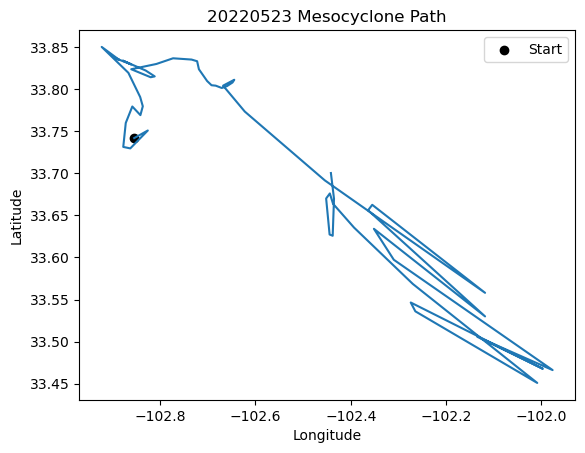

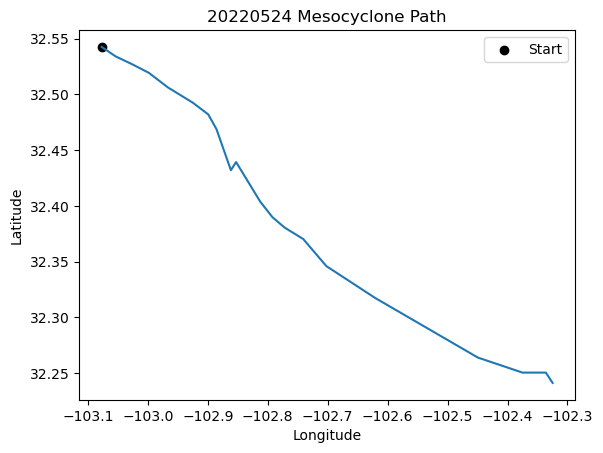

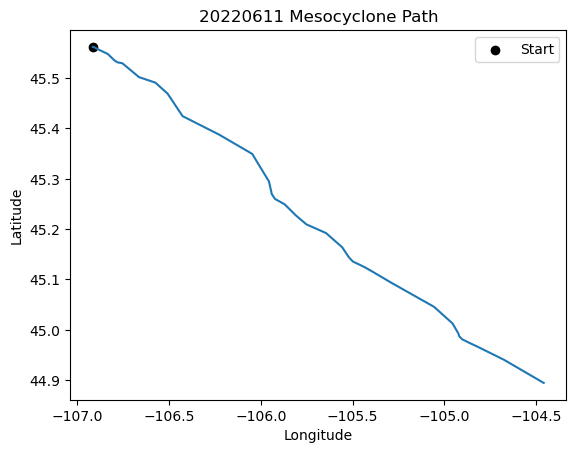

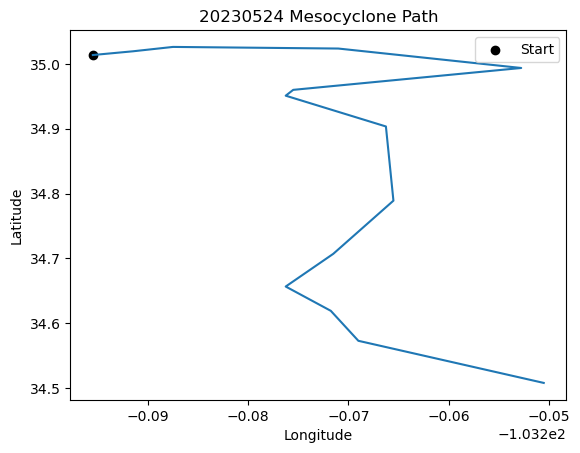

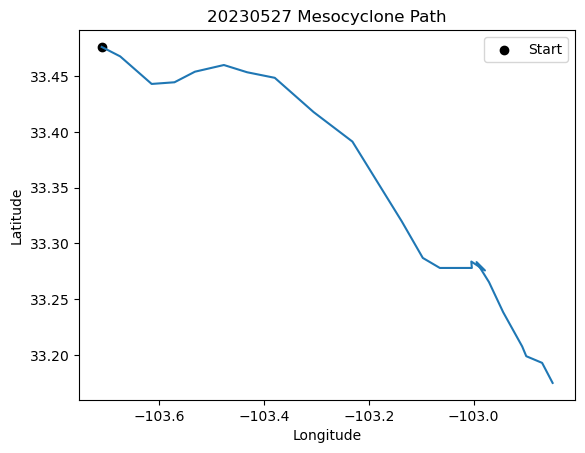

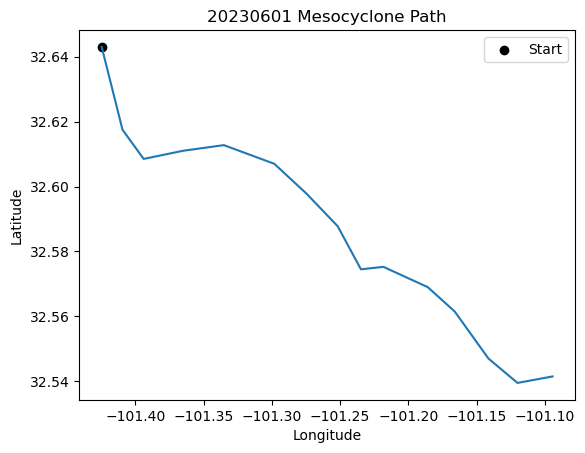

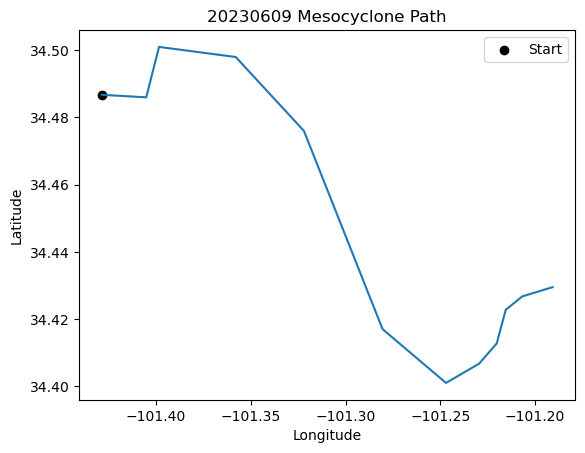

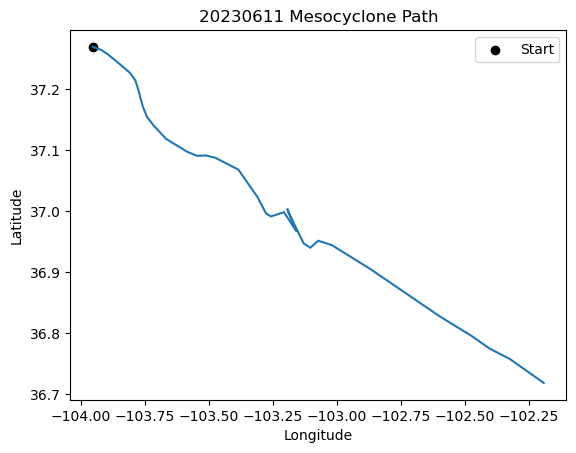

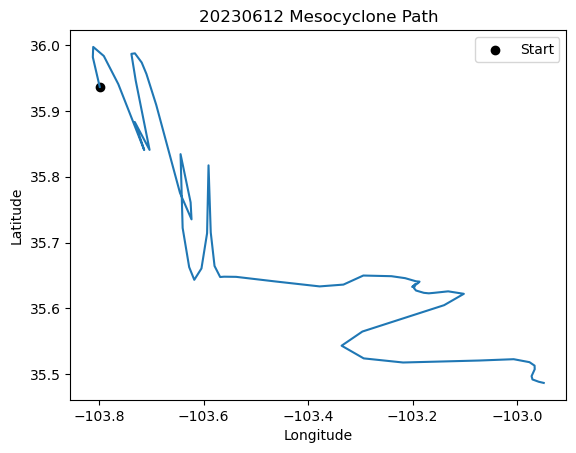

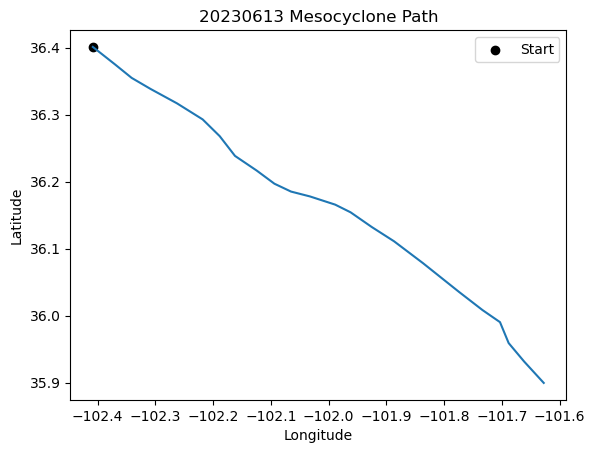

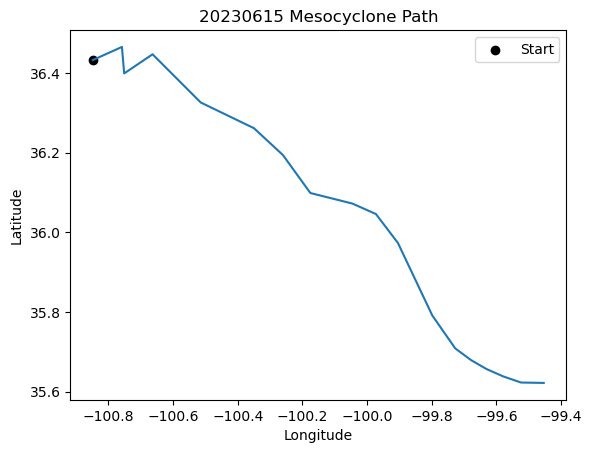

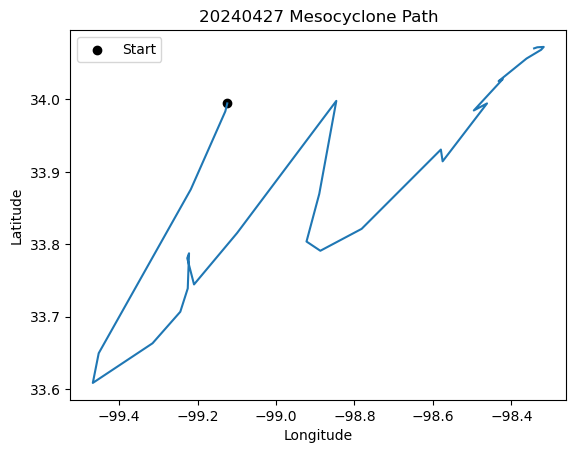

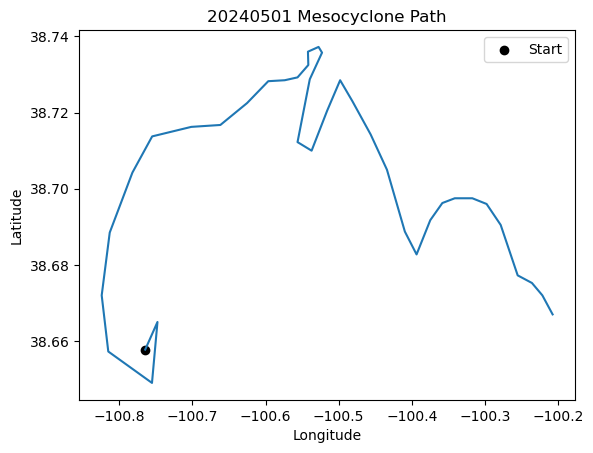

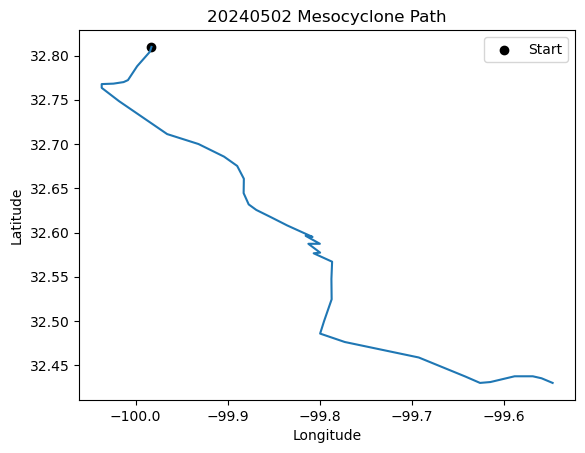

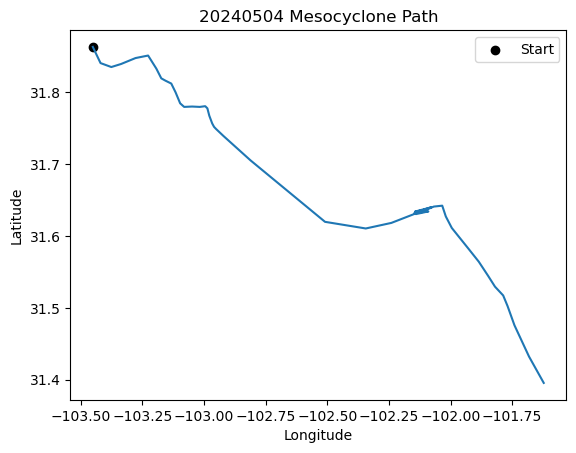

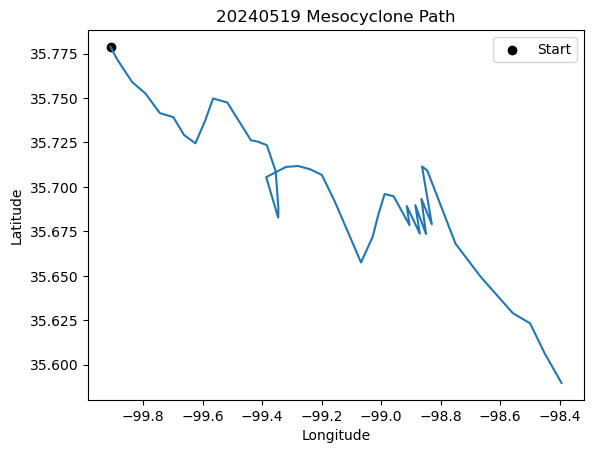

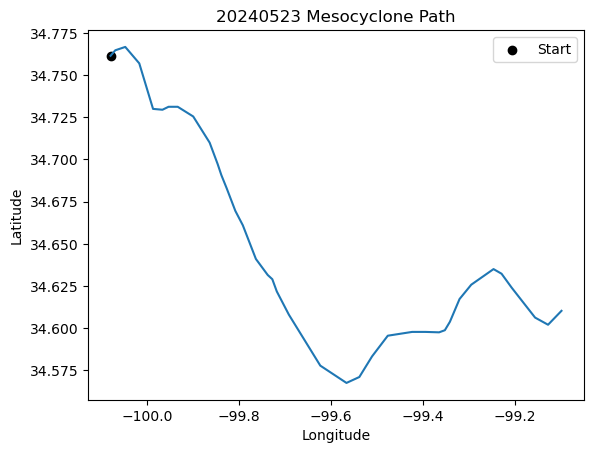

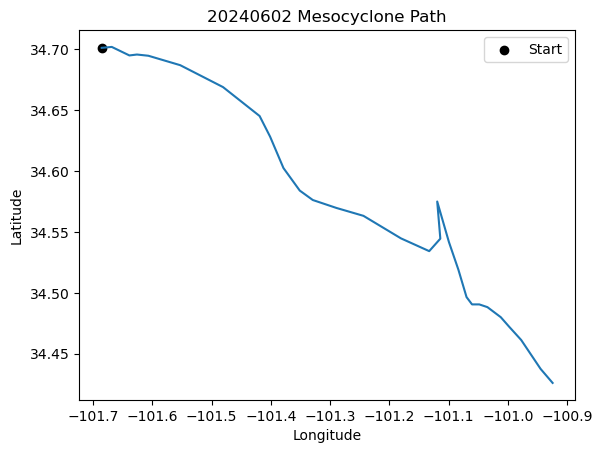

In [17]:
for d in meso_ids_dict:
    date_select = meso_location[meso_location['Date'] == d]
    plt.figure()
    plt.plot(date_select['Meso_Lon'], date_select['Meso_Lat'])
    plt.title(f'{d} Mesocyclone Path')
    plt.scatter(date_select['Meso_Lon'].iloc[0], date_select['Meso_Lat'].iloc[0], label='Start', marker='o', color='k')
    plt.legend()
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

In [18]:
meso_location[meso_location['Date'] == '20220524'].loc[70]

Meso_Lat                32.3175
Meso_Lon            -102.621001
Date                   20220524
Time        2022-05-24 21:24:15
Name: 70, dtype: object

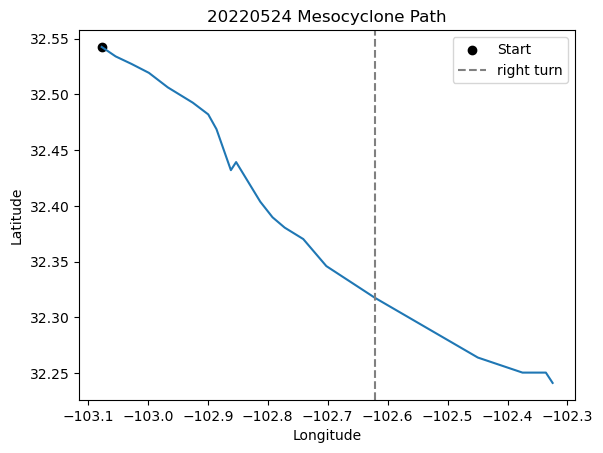

In [19]:
date_select = meso_location[meso_location['Date'] == '20220524']
plt.figure()
plt.plot(date_select['Meso_Lon'], date_select['Meso_Lat'])
plt.title('20220524 Mesocyclone Path')
plt.scatter(date_select['Meso_Lon'].iloc[0], date_select['Meso_Lat'].iloc[0], label='Start', marker='o', color='k')
plt.axvline(date_select.loc[70]['Meso_Lon'], linestyle='--', color='gray', label='right turn')
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Test Cases

In [20]:
df_copy['NF or FF'] = np.where(df_copy['Distance'] <= 30, 'nf', 'ff')

In [21]:
def right_turn_time(date, date_utc):
    
    test_case4 = df_copy[(df_copy['Date'] == date)]
    rt_time = pd.Timestamp(date_utc)
    
    test_case4['Right Turn'] = np.where(test_case4['Datetime Int'] < rt_time,
                                       'before',
                                       'after'
                                      )
    return test_case4

In [22]:
test_case = right_turn_time('20220524', '2022-05-24 21:36:20')

In [23]:
test_case['Right Turn'].value_counts()

Right Turn
before    100
Name: count, dtype: int64

In [80]:
pd.crosstab(test_case['Right Turn'], test_case['NF or FF'])

NF or FF,nf
Right Turn,
before,100


Hmm, only before-turn VADs, not good test case. Let's try another.

In [24]:
df_copy['Date'].value_counts()

Date
20230615    924
20240501    850
20230527    506
20230611    388
20240427    314
20230524    284
20240602    262
20230612    198
20220523    140
20220524    100
20230613     20
Name: count, dtype: int64

In [25]:
test_case2 = right_turn_time('20230527', '2023-05-28 01:14:00')

In [26]:
test_case2['Right Turn'].value_counts()

Right Turn
before    392
after     114
Name: count, dtype: int64

In [28]:
pd.crosstab(test_case2['Right Turn'], test_case2['NF or FF'])

NF or FF,ff,nf
Right Turn,,
after,0,114
before,180,212


Let's make some hodographs just to see

In [29]:
def before_after_uv_avg(test_case2):
    before = test_case2[test_case2['Right Turn'] == 'before']
    after = test_case2[test_case2['Right Turn'] == 'after']
    
    before_avg_u = np.nanmean(before[before['u or v'] == 'u'].iloc[:, :196],axis=0)
    before_avg_v = np.nanmean(before[before['u or v'] == 'v'].iloc[:, :196],axis=0)
    
    after_avg_u = np.nanmean(after[after['u or v'] == 'u'].iloc[:, :196],axis=0)
    after_avg_v = np.nanmean(after[after['u or v'] == 'v'].iloc[:, :196],axis=0)

    return before_avg_u, before_avg_v, after_avg_u, after_avg_v

In [94]:
def bef_af_nf_ff_avg(test_case2):
    profiles = (
        test_case2
        .groupby(['Right Turn', 'NF or FF', 'u or v'])
        .apply(lambda df: np.nanmean(df.iloc[:, :196], axis=0))
    )
    before_avg_u_nf = profiles[('before', 'nf', 'u')]
    before_avg_v_nf = profiles[('before', 'nf', 'v')]
    
    before_avg_u_ff = profiles[('before', 'ff', 'u')]
    before_avg_v_ff = profiles[('before', 'ff', 'v')]
    
    after_avg_u_nf = profiles[('after', 'nf', 'u')]
    after_avg_v_nf = profiles[('after', 'nf', 'v')]
    
    after_avg_u_ff = profiles[('after', 'ff', 'u')]
    after_avg_v_ff = profiles[('after', 'ff', 'v')]

    return before_avg_u_nf, before_avg_v_nf, before_avg_u_ff, before_avg_v_ff, after_avg_u_nf, after_avg_v_nf, after_avg_u_ff, after_avg_v_ff

In [ ]:
before_avg_u, before_avg_v, after_avg_u, after_avg_v = before_after_uv_avg(test_case2)
before_avg_u_nf, before_avg_v_nf, after_avg_u_ff, after_avg_v_ff = bef_af_nf_ff_avg(test_case2)

In [31]:
def hodo_plot(u_list, v_list, heights, component_range, title, color_list, label_list, lower_limit, upper_limit, legend_position, figsizex, figsizey):
    '''
    component_range = single number, how far you want the hodograph plot to extent in m/s
    colors = list of strings of desired colors for hodograph, amount of colors must be = to # of boundary intervals
    '''
    
    from matplotlib import rcParams, rcParamsDefault
    import matplotlib.patheffects as pe
    rcParams.update(rcParamsDefault)
    fig, ax = plt.subplots(1, 1, figsize=(figsizex, figsizey))
    hodo = metpy.plots.Hodograph(ax, component_range=component_range)
    hodo.add_grid(increment=5)
    ax.set_xlim(-upper_limit, lower_limit)  # Only negative x values
    ax.set_ylim(-lower_limit, upper_limit)     
    for speed in np.arange(10, 40, 10):  # Adjust range according to your increment and component range
        x = speed / np.sqrt(2)
        y = speed / np.sqrt(2)
        ax.text(-x, y, f'{speed} m/s', color='gray', fontsize=10, ha='center', va='bottom')
    
    #colors = [[0.8,0.3,0.3,1],[0.2,0.7,0.3,1],[0.4,0.9,0.8,1], [0.7,0.4,0.7,1]]
    boundaries = [50, 500, 1000, 1500, 2000]
    
    for u, v, color, label in zip(u_list, v_list, color_list, label_list):
        h = hodo.plot_colormapped(u, v, heights, color= color, label=label, linewidth=3)
    # hodo.wind_vectors(nearfield_u_grady[0], nearfield_v_grady[0], label = 'Storm-Relative Wind Vector (m/s)')
    # hodo.wind_vectors(nearfield_u_grady[99], nearfield_v_grady[99])
    # hodo.wind_vectors(nearfield_u_grady[195], nearfield_v_grady[195])
    
    #ax.scatter(0,0, 'ko')
    ax.set_xlabel('Average U-component Wind (m/s)', fontsize=13)
    ax.set_ylabel('Average V-component Wind (m/s)', fontsize=13)
    ax.set_title(f'{title}', fontsize=13,fontweight='bold', wrap=True)

    for u,v,color in zip(u_list, v_list, color_list):
        
        #for i,z in zip([0, 0.5, 1, 2], enumerate([0,45,95,195])):
        for i,z in zip([0, 0.5, 1, 2], [0,45,95,195]):
            try:
                if np.isnan(u[z]):
                    pass
                else:
                    circle = plt.Circle((u[z], v[z]), radius=0.7,color=color,zorder=30, alpha=0.5)
                    ax.add_patch(circle)
                    label = ax.annotate(i, xy=(u[z], v[z]), fontsize=8, ha="center",va='center',color='white',zorder=30,weight="bold", path_effects=[pe.withStroke(linewidth=3, foreground='black')])
            # path_effects lets you put an outline around your text
            except: pass
    
    #ax.text(0.71, 0.96, 'Storm-Relative', transform = ax.transAxes, fontsize = 13, verticalalignment='center', color='white', bbox=dict(facecolor='blue', alpha=0.5))
    #plt.colorbar(h, label = 'Height (m above sea level)', shrink = 0.80)
    
    plt.plot(0,0, 'x', markersize = 20, label = 'Observed Storm Motion', color = 'black', markeredgewidth = 3)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.legend(loc=legend_position, fontsize=13)
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/{title}', bbox_inches='tight')
    plt.show()

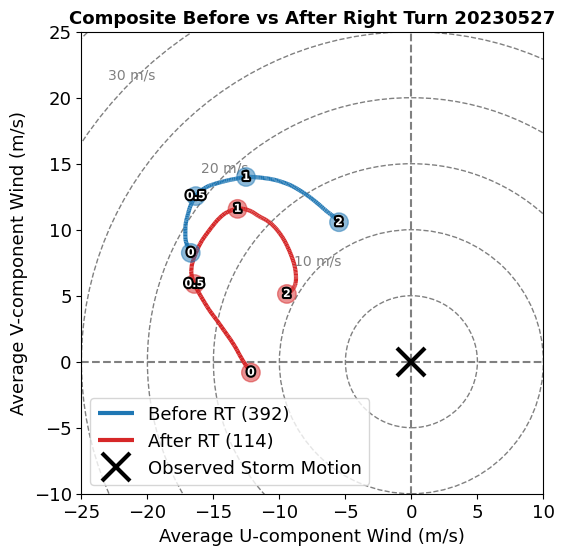

In [32]:
d = '20230527'
heights = np.arange(50, 2010, 10)

hodo_plot([before_avg_u, after_avg_u], [before_avg_v, after_avg_v], heights, 25, f'Composite Before vs After Right Turn {d}', ['tab:blue', 'tab:red'], 
          [f'Before RT ({test_case2['Right Turn'].value_counts()[0]})', f'After RT ({test_case2['Right Turn'].value_counts()[1]})'],
          10, 25, 'lower left', 6,6)

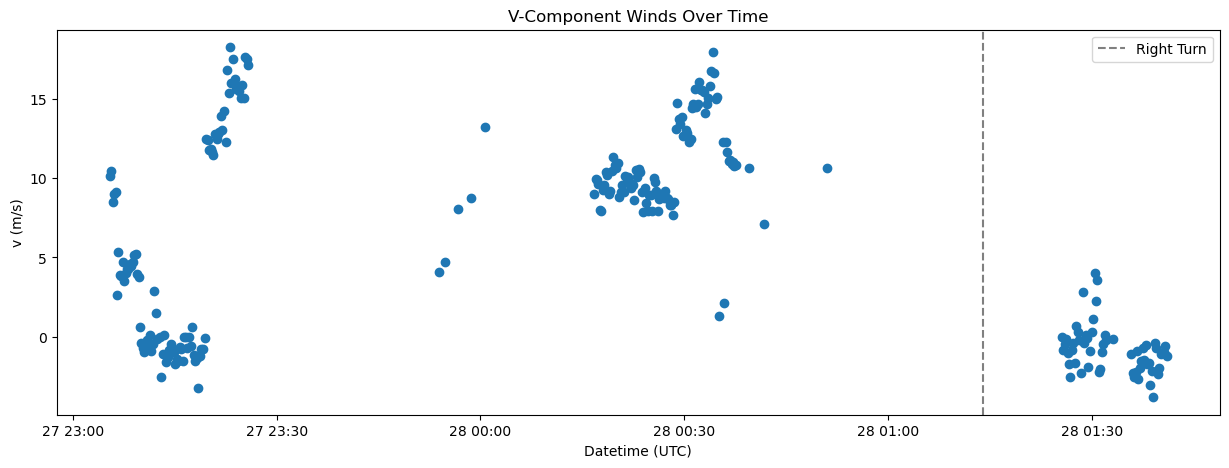

In [35]:
rt_time = pd.Timestamp('2023-05-28 01:14:00')
plt.figure(figsize=(15,5))
plt.scatter(test_case2[test_case2['u or v'] == 'v']['Datetime Int'], test_case2[test_case2['u or v'] == 'v']['0'])
plt.xlabel('Datetime (UTC)')
plt.ylabel('v (m/s)')
plt.axvline(rt_time, linestyle='--', color='gray', label='Right Turn')
plt.legend()
plt.title('V-Component Winds Over Time')
plt.show()

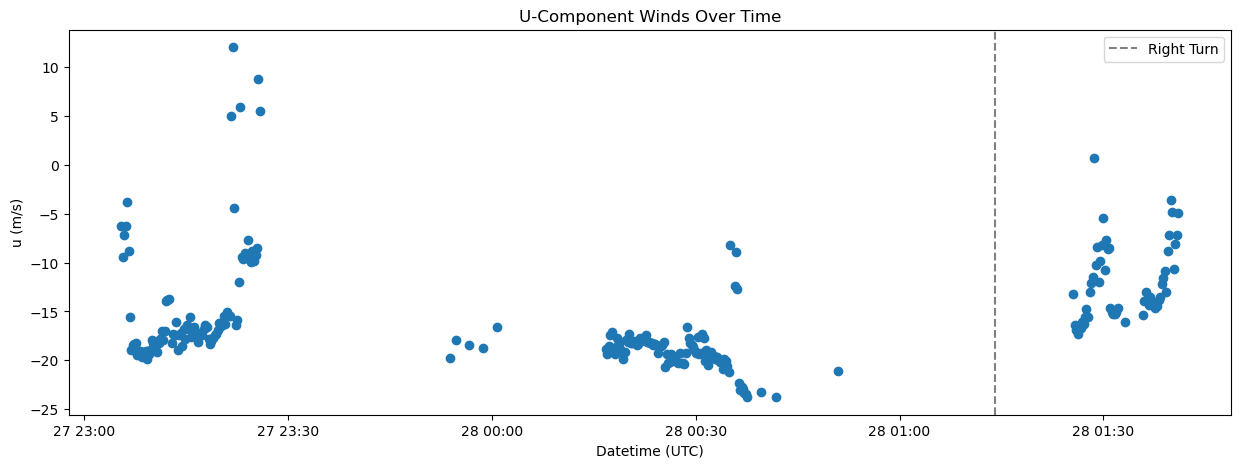

In [36]:
plt.figure(figsize=(15,5))
plt.scatter(test_case2[test_case2['u or v'] == 'u']['Datetime Int'], test_case2[test_case2['u or v'] == 'u']['0'])
plt.xlabel('Datetime (UTC)')
plt.ylabel('u (m/s)')
plt.axvline(rt_time, linestyle='--', color='gray', label='Right Turn')
plt.legend()
plt.title('U-Component Winds Over Time')
plt.show()

In [116]:
meso_azshear_df

,Time,Meso_Max,Date
0,2022-05-23 22:56:28,5.00000,20220523
1,2022-05-23 22:56:28,5.00000,20220523
2,2022-05-23 22:56:28,5.00000,20220523
3,2022-05-23 22:56:28,5.00000,20220523
4,2022-05-23 22:56:28,5.00000,20220523
...,...,...,...
3981,2024-06-03 02:16:20,7.05557,20240602
3982,2024-06-03 02:16:20,7.05557,20240602
3983,2024-06-03 02:16:20,7.05557,20240602
3984,2024-06-03 02:16:20,7.05557,20240602


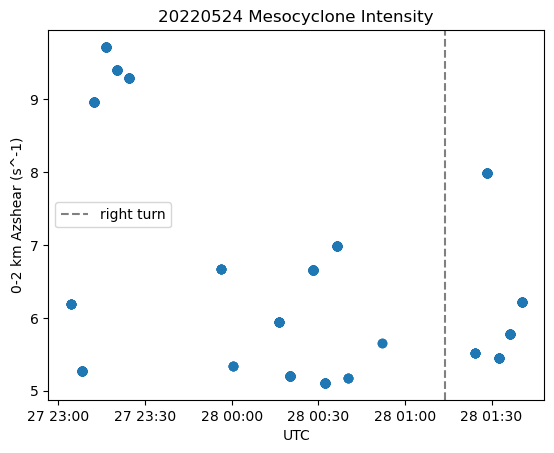

In [148]:
date_select = meso_azshear_df[meso_azshear_df['Date'] == '20230527']
rt_time = pd.Timestamp('2023-05-28 01:14:00')
plt.figure()
plt.scatter(date_select['Time'], date_select['Meso_Max'])
plt.title('20220524 Mesocyclone Intensity')
plt.axvline(rt_time, linestyle='--', color='gray', label='right turn')
plt.legend()
plt.xlabel('UTC')
plt.ylabel('0-2 km Azshear (s^-1)')
plt.show()

In [37]:
def composite_srh_nan(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in range(len(u)-1):
        a = np.nanprod([u[i+1], v[i]], axis=0)
        b = -np.nanprod([u[i], v[i+1]], axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh_total

In [38]:
def calc_srh_for_heights(test_case2):
    
    srh_2km = [composite_srh_nan(test_case2[test_case2['u or v'] == 'u'].iloc[i,:196], test_case2[test_case2['u or v'] == 'v'].iloc[i,:196])
            for i in range(len(test_case2[test_case2['u or v'] == 'u']))]

    srh_1km = [composite_srh_nan(test_case2[test_case2['u or v'] == 'u'].iloc[i,:100], test_case2[test_case2['u or v'] == 'v'].iloc[i,:100])
                for i in range(len(test_case2[test_case2['u or v'] == 'u']))]
    
    srh_500m = [composite_srh_nan(test_case2[test_case2['u or v'] == 'u'].iloc[i,:50], test_case2[test_case2['u or v'] == 'v'].iloc[i,:50])
                for i in range(len(test_case2[test_case2['u or v'] == 'u']))]
    
    srh_100m = [composite_srh_nan(test_case2[test_case2['u or v'] == 'u'].iloc[i,:10], test_case2[test_case2['u or v'] == 'v'].iloc[i,:10])
                for i in range(len(test_case2[test_case2['u or v'] == 'u']))]

    return srh_2km, srh_1km, srh_500m, srh_100m

In [39]:
srh_2km, srh_1km, srh_500m, srh_100m = calc_srh_for_heights(test_case2)

In [40]:
def name_columns(test_case2, variable, srh_2km, srh_1km, srh_500m, srh_100m):
    test_case2.loc[test_case2[test_case2['u or v'] == 'u'].index, f'{variable}02km'] = srh_2km
    test_case2.loc[test_case2[test_case2['u or v'] == 'v'].index, f'{variable}02km'] = srh_2km
    
    test_case2.loc[test_case2[test_case2['u or v'] == 'u'].index, f'{variable}01km'] = srh_1km
    test_case2.loc[test_case2[test_case2['u or v'] == 'v'].index, f'{variable}01km'] = srh_1km
    
    test_case2.loc[test_case2[test_case2['u or v'] == 'u'].index, f'{variable}0500m'] = srh_500m
    test_case2.loc[test_case2[test_case2['u or v'] == 'v'].index, f'{variable}0500m'] = srh_500m
    
    test_case2.loc[test_case2[test_case2['u or v'] == 'u'].index, f'{variable}0100m'] = srh_100m
    test_case2.loc[test_case2[test_case2['u or v'] == 'v'].index, f'{variable}0100m'] = srh_100m

In [42]:
name_columns(test_case2, 'SRH', srh_2km, srh_1km, srh_500m, srh_100m)

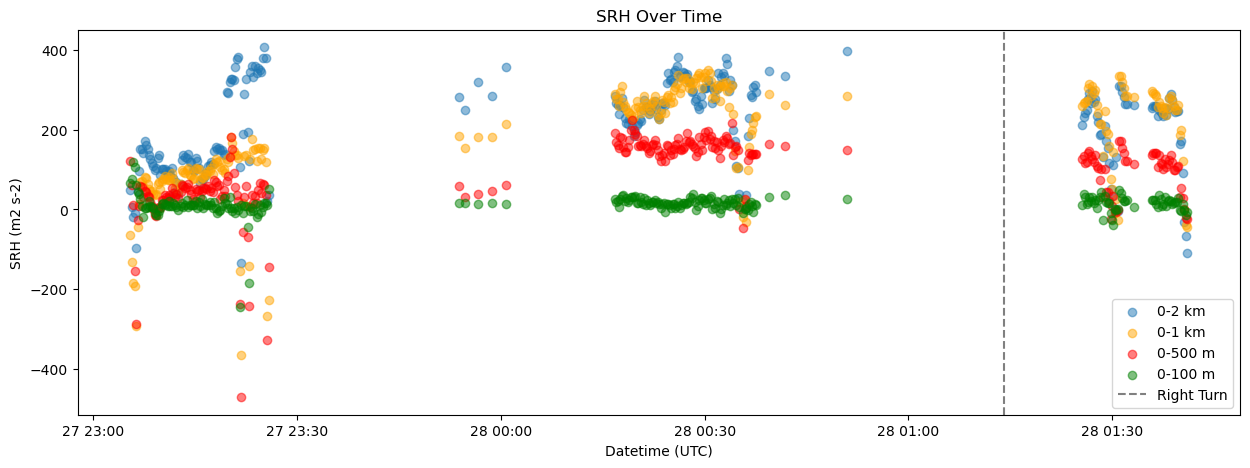

In [43]:
plt.figure(figsize=(15,5))
plt.scatter(test_case2[test_case2['u or v'] == 'u']['Datetime Int'], test_case2[test_case2['u or v'] == 'u']['SRH02km'], label='0-2 km', alpha=0.5)
plt.scatter(test_case2[test_case2['u or v'] == 'u']['Datetime Int'], test_case2[test_case2['u or v'] == 'u']['SRH01km'], label='0-1 km', color='orange', alpha=0.5)
plt.scatter(test_case2[test_case2['u or v'] == 'u']['Datetime Int'], test_case2[test_case2['u or v'] == 'u']['SRH0500m'], color='red', label='0-500 m', alpha=0.5)
plt.scatter(test_case2[test_case2['u or v'] == 'u']['Datetime Int'], test_case2[test_case2['u or v'] == 'u']['SRH0100m'], color='green', label='0-100 m', alpha=0.5)
plt.xlabel('Datetime (UTC)')
plt.ylabel('SRH (m2 s-2)')
plt.axvline(rt_time, linestyle='--', color='gray', label='Right Turn')
plt.legend()
plt.title('SRH Over Time')
plt.show()

Okay, let's try a nontornadic day:

In [44]:
test_case3 = right_turn_time('20240501', '2024-05-02 00:40:00')

In [45]:
test_case3['Right Turn'].value_counts()

Right Turn
before    532
after     318
Name: count, dtype: int64

In [82]:
pd.crosstab(test_case3['Right Turn'], test_case3['NF or FF'])

NF or FF,ff,nf
Right Turn,,
after,140,178
before,408,124


In [110]:
bef_u, bef_v, af_u, af_v = before_after_uv_avg(test_case3)
before_avg_u_nf, before_avg_v_nf, before_avg_u_ff, before_avg_v_ff, after_avg_u_nf, after_avg_v_nf, after_avg_u_ff, after_avg_v_ff = bef_af_nf_ff_avg(test_case3)

In [47]:
case3_srh2k, case3_srh1k, case3_srh5, case3_srh1 = calc_srh_for_heights(test_case3)

In [48]:
name_columns(test_case3, 'SRH', case3_srh2k, case3_srh1k, case3_srh5, case3_srh1)

In [49]:
test_case3

,0,1,2,3,4,5,6,7,8,9,...,Date,Tor or Nontor,Meso Max,Datetime Int,NF or FF,Right Turn,SRH02km,SRH01km,SRH0500m,SRH0100m
2874,-5.289428,-5.367832,-5.447642,-5.517880,-5.517880,-5.678765,-5.742806,-5.858631,-5.925425,-6.012227,...,20240501,nontor,7.253094,2024-05-01 23:07:23,nf,before,34.604085,21.201866,10.957417,0.263519
2875,-6.193625,-6.261240,-6.306361,-6.345175,-6.345175,-6.418840,-6.438904,-6.484085,-6.501603,-6.505513,...,20240501,nontor,7.253094,2024-05-01 23:07:36,nf,before,39.952999,26.934710,16.227581,5.458699
2876,-7.056421,-7.115969,-7.078659,-6.988845,-6.988845,-6.916841,-6.818472,-6.654284,-6.538125,-6.425287,...,20240501,nontor,7.253094,2024-05-01 23:07:49,nf,before,49.415266,35.511599,24.288248,10.582805
2877,-6.443501,-6.377501,-6.275063,-6.181563,-6.181563,-6.039698,-6.004709,-5.917413,-5.851793,-5.847346,...,20240501,nontor,7.253094,2024-05-01 23:08:01,nf,before,18.886658,4.248801,14.160234,10.762070
2878,-5.307336,-5.307132,-5.316027,-5.340261,-5.340261,-5.389801,-5.465766,-5.586229,-5.642135,-5.801606,...,20240501,nontor,7.253094,2024-05-01 23:08:14,nf,before,-14.613086,-29.993726,12.138772,-5.243379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3719,-13.090294,-12.287021,-11.154627,-10.072467,-10.072467,-8.267106,-7.560733,-6.085891,-5.166974,-4.224521,...,20240501,nontor,12.157411,2024-05-02 02:02:55,nf,after,311.008757,311.008757,265.032004,152.181018
3720,4.491125,5.282521,5.701219,5.992428,5.992428,6.684772,6.892005,7.432511,7.545950,7.975916,...,20240501,nontor,12.157411,2024-05-02 02:03:08,nf,after,165.503891,150.820049,147.219467,32.799340
3721,14.987909,15.820668,16.351990,16.793095,16.793095,17.935064,18.183987,18.680830,18.919762,19.335417,...,20240501,nontor,12.157411,2024-05-02 02:03:48,nf,after,213.421931,213.421931,157.091630,44.009325
3722,4.221482,4.711701,4.915419,5.217384,5.217384,5.952429,6.218968,6.716082,6.920869,7.417392,...,20240501,nontor,12.157411,2024-05-02 02:04:15,nf,after,314.412017,314.412017,75.140736,29.059878


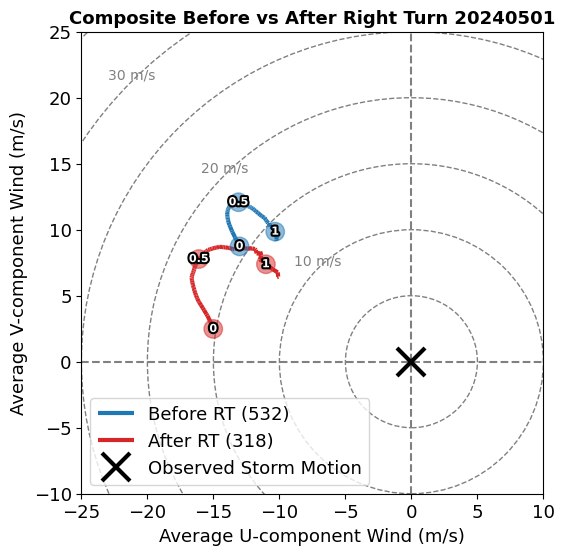

In [50]:
d = '20240501'
heights = np.arange(50, 2010, 10)

hodo_plot([bef_u, af_u], [bef_v, af_v], heights, 25, f'Composite Before vs After Right Turn {d}', ['tab:blue', 'tab:red'], [f'Before RT ({test_case3['Right Turn'].value_counts()[0]})', 
                                                                                                                            f'After RT ({test_case3['Right Turn'].value_counts()[1]})'],
          10, 25, 'lower left', 6,6)

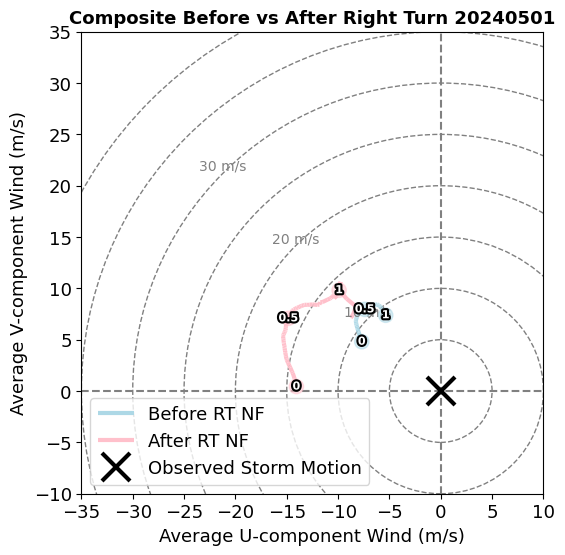

In [111]:
d = '20240501'
heights = np.arange(50, 2010, 10)

hodo_plot([before_avg_u_nf, after_avg_u_nf], [before_avg_v_nf, after_avg_v_nf], heights, 30, 
          f'Composite Before vs After Right Turn {d}', ['lightblue', 'pink'], [f'Before RT NF', 'After RT NF'
                                                                                                               ],
          10, 35, 'lower left', 6,6)

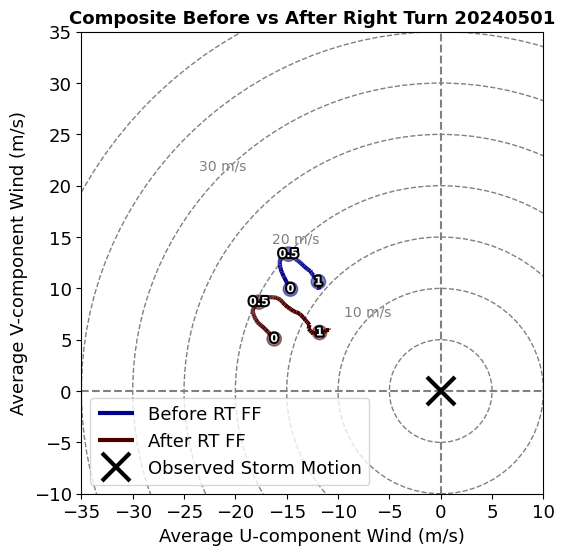

In [112]:
d = '20240501'
heights = np.arange(50, 2010, 10)

hodo_plot([before_avg_u_ff, after_avg_u_ff], [before_avg_v_ff, after_avg_v_ff], heights, 30, 
          f'Composite Before vs After Right Turn {d}', ['darkblue', very_dark_red], ['Before RT FF', 'After RT FF'
                                                                                                               ],
          10, 35, 'lower left', 6,6)

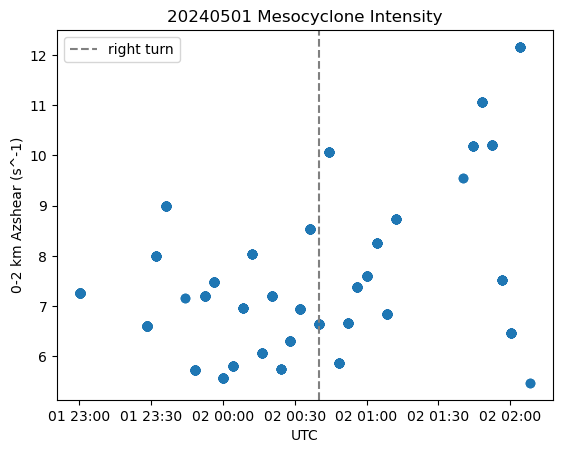

In [149]:
date_select = meso_azshear_df[meso_azshear_df['Date'] == '20240501']
rt_time = pd.Timestamp('2024-05-02 00:40:00')
plt.figure()
plt.scatter(date_select['Time'], date_select['Meso_Max'])
plt.title('20240501 Mesocyclone Intensity')
plt.axvline(rt_time, linestyle='--', color='gray', label='right turn')
plt.legend()
plt.xlabel('UTC')
plt.ylabel('0-2 km Azshear (s^-1)')
plt.show()

In [51]:
def plot_stuff(test_case2, date, rt_time):
    plt.figure(figsize=(15,5))
    plt.scatter(test_case2[test_case2['u or v'] == 'u']['Datetime Int'], test_case2[test_case2['u or v'] == 'u']['SRH02km'], label='0-2 km', alpha=0.5)
    plt.scatter(test_case2[test_case2['u or v'] == 'u']['Datetime Int'], test_case2[test_case2['u or v'] == 'u']['SRH01km'], label='0-1 km', color='orange', alpha=0.5)
    plt.scatter(test_case2[test_case2['u or v'] == 'u']['Datetime Int'], test_case2[test_case2['u or v'] == 'u']['SRH0500m'], color='red', label='0-500 m', alpha=0.5)
    plt.scatter(test_case2[test_case2['u or v'] == 'u']['Datetime Int'], test_case2[test_case2['u or v'] == 'u']['SRH0100m'], color='green', label='0-100 m', alpha=0.5)
    plt.xlabel('Datetime (UTC)')
    plt.ylabel('SRH (m2 s-2)')
    plt.axvline(rt_time, linestyle='--', color='gray', label='Right Turn')
    plt.legend()
    plt.title(f'SRH Over Time {date}')
    plt.show()

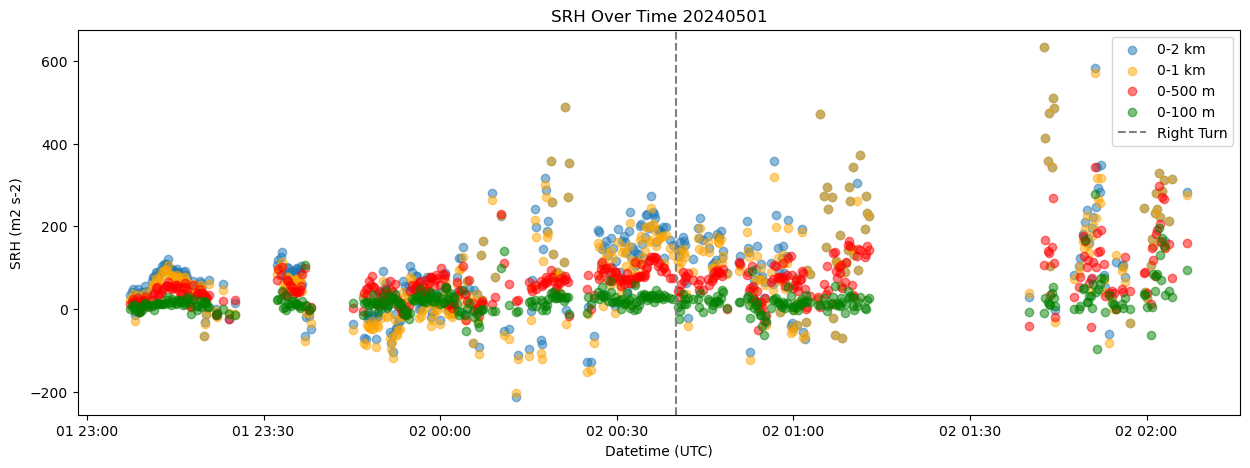

In [52]:
rt_time = pd.Timestamp('2024-05-02 00:40:00')
plot_stuff(test_case3, '20240501', rt_time)

Another one:

In [53]:
test_case4 = right_turn_time('20230611', '2023-06-11 20:50:00')

In [54]:
test_case4['Right Turn'].value_counts()

Right Turn
after    388
Name: count, dtype: int64

In [83]:
pd.crosstab(test_case4['Right Turn'], test_case4['NF or FF'])

NF or FF,ff,nf
Right Turn,,
after,80,308


In [55]:
bef_u, bef_v, af_u, af_v = before_after_uv_avg(test_case4)
case4_srh2k, case4_srh1k, case4_srh5, case4_srh1 = calc_srh_for_heights(test_case4)

In [56]:
name_columns(test_case4, 'SRH', case4_srh2k, case4_srh1k, case4_srh5, case4_srh1)

In [57]:
d = '20230611'
heights = np.arange(50, 2010, 10)

hodo_plot([bef_u, af_u], [bef_v, af_v], heights, 25, f'Composite Before vs After Right Turn {d}', ['tab:blue', 'tab:red'], [f'Before RT ({test_case4['Right Turn'].value_counts()[0]})', 
                                                                                                                            f'After RT ({test_case4['Right Turn'].value_counts()[1]})'],
          10, 25, 'lower left', 6,6)

IndexError: index 1 is out of bounds for axis 0 with size 1

In [58]:
test_case5 = right_turn_time('20230615', '2023-06-15 23:45:00')

In [59]:
test_case5['Right Turn'].value_counts()

Right Turn
after     656
before    268
Name: count, dtype: int64

In [84]:
pd.crosstab(test_case5['Right Turn'], test_case5['NF or FF'])

NF or FF,ff,nf
Right Turn,,
after,270,386
before,226,42


In [95]:
bef_u, bef_v, af_u, af_v = before_after_uv_avg(test_case5)
before_avg_u_nf, before_avg_v_nf, before_avg_u_ff, before_avg_v_ff, after_avg_u_nf, after_avg_v_nf, after_avg_u_ff, after_avg_v_ff = bef_af_nf_ff_avg(test_case5)
case5_srh2k, case5_srh1k, case5_srh5, case5_srh1 = calc_srh_for_heights(test_case5)

In [61]:
name_columns(test_case5, 'SRH', case5_srh2k, case5_srh1k, case5_srh5, case5_srh1)

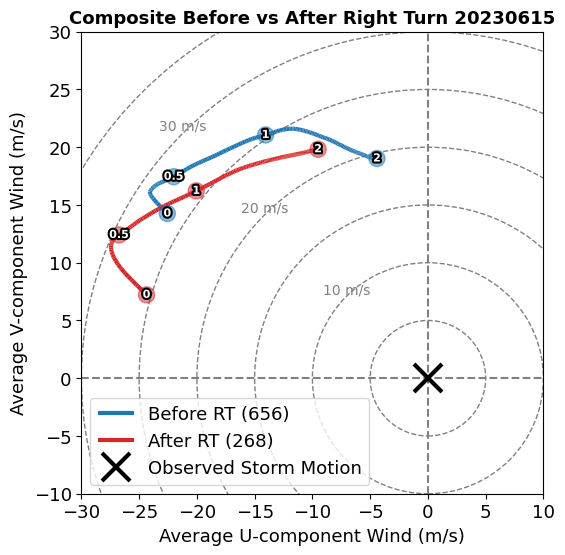

In [96]:
d = '20230615'
heights = np.arange(50, 2010, 10)

hodo_plot([bef_u, af_u], [bef_v, af_v], heights, 25, f'Composite Before vs After Right Turn {d}', ['tab:blue', 'tab:red'], [f'Before RT ({test_case5['Right Turn'].value_counts()[0]})', 
                                                                                                                            f'After RT ({test_case5['Right Turn'].value_counts()[1]})'],
          10, 30, 'lower left', 6,6)

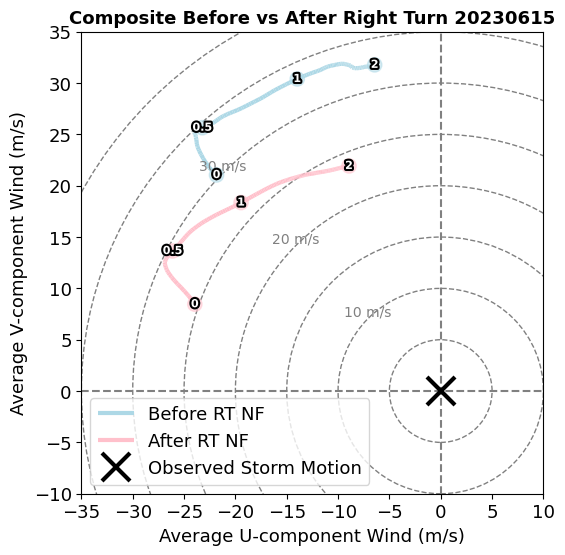

In [103]:
d = '20230615'
heights = np.arange(50, 2010, 10)

hodo_plot([before_avg_u_nf, after_avg_u_nf], [before_avg_v_nf, after_avg_v_nf], heights, 30, 
          f'Composite Before vs After Right Turn {d}', ['lightblue', 'pink'], [f'Before RT NF', 'After RT NF'
                                                                                                               ],
          10, 35, 'lower left', 6,6)

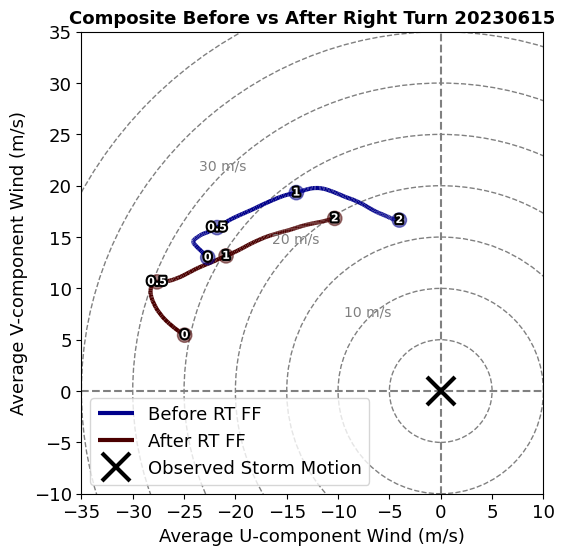

In [101]:
d = '20230615'
heights = np.arange(50, 2010, 10)

hodo_plot([before_avg_u_ff, after_avg_u_ff], [before_avg_v_ff, after_avg_v_ff], heights, 30, 
          f'Composite Before vs After Right Turn {d}', ['darkblue', very_dark_red], ['Before RT FF', 'After RT FF'
                                                                                                               ],
          10, 35, 'lower left', 6,6)

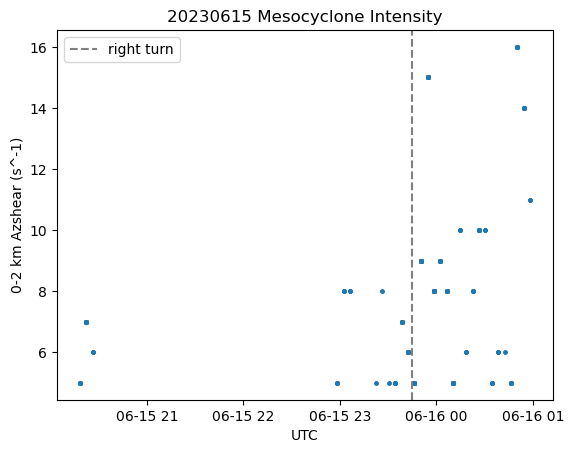

In [147]:
date = '20230615'
date_select = meso_azshear_df[meso_azshear_df['Date'] == date]
rt_time = pd.Timestamp('2023-06-15 23:45:00')
plt.figure()
plt.scatter(date_select['Time'], date_select['Meso_Max'], s=5)
plt.title(f'{date} Mesocyclone Intensity')
plt.axvline(rt_time, linestyle='--', color='gray', label='right turn')
plt.legend()
plt.xlabel('UTC')
plt.ylabel('0-2 km Azshear (s^-1)')
plt.show()

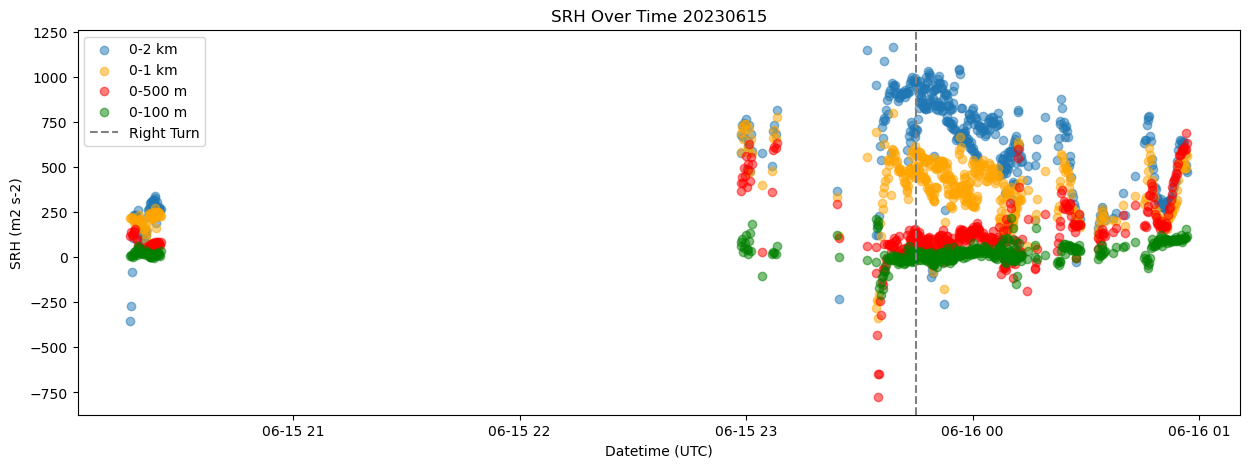

In [63]:
rt_time = pd.Timestamp('2023-06-15 23:45:00')
plot_stuff(test_case5, '20230615', rt_time)

In [64]:
test_case6 = right_turn_time('20240427', '2024-04-27 19:30:00')
test_case6['Right Turn'].value_counts()

Right Turn
after    314
Name: count, dtype: int64

In [85]:
pd.crosstab(test_case6['Right Turn'], test_case6['NF or FF'])

NF or FF,ff,nf
Right Turn,,
after,180,134


In [65]:
test_case7 = right_turn_time('20240602', '2024-06-03 00:40:00')
test_case7['Right Turn'].value_counts()

Right Turn
after     198
before     64
Name: count, dtype: int64

In [86]:
pd.crosstab(test_case7['Right Turn'], test_case7['NF or FF'])

NF or FF,nf
Right Turn,
after,198
before,64


In [66]:
bef_u, bef_v, af_u, af_v = before_after_uv_avg(test_case7)
case7_srh2k, case7_srh1k, case7_srh5, case7_srh1 = calc_srh_for_heights(test_case7)

In [67]:
name_columns(test_case7, 'SRH', case7_srh2k, case7_srh1k, case7_srh5, case7_srh1)

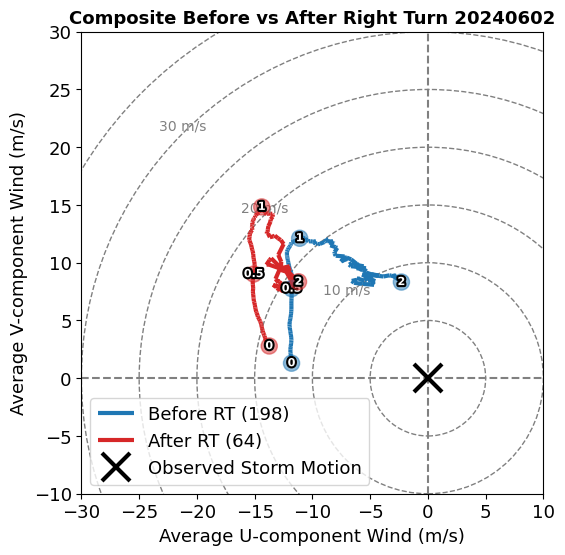

In [68]:
d = '20240602'
heights = np.arange(50, 2010, 10)

hodo_plot([bef_u, af_u], [bef_v, af_v], heights, 25, f'Composite Before vs After Right Turn {d}', ['tab:blue', 'tab:red'], [f'Before RT ({test_case7['Right Turn'].value_counts()[0]})', 
                                                                                                                            f'After RT ({test_case7['Right Turn'].value_counts()[1]})'],
          10, 30, 'lower left', 6,6)

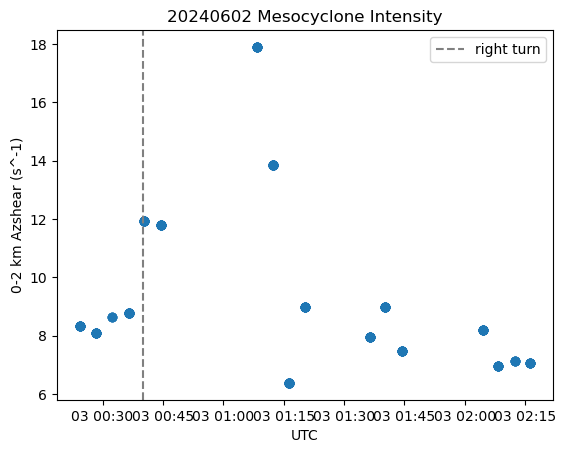

In [150]:
date = '20240602'
date_select = meso_azshear_df[meso_azshear_df['Date'] == date]
rt_time = pd.Timestamp('2024-06-03 00:40:00')
plt.figure()
plt.scatter(date_select['Time'], date_select['Meso_Max'])
plt.title(f'{date} Mesocyclone Intensity')
plt.axvline(rt_time, linestyle='--', color='gray', label='right turn')
plt.legend()
plt.xlabel('UTC')
plt.ylabel('0-2 km Azshear (s^-1)')
plt.show()

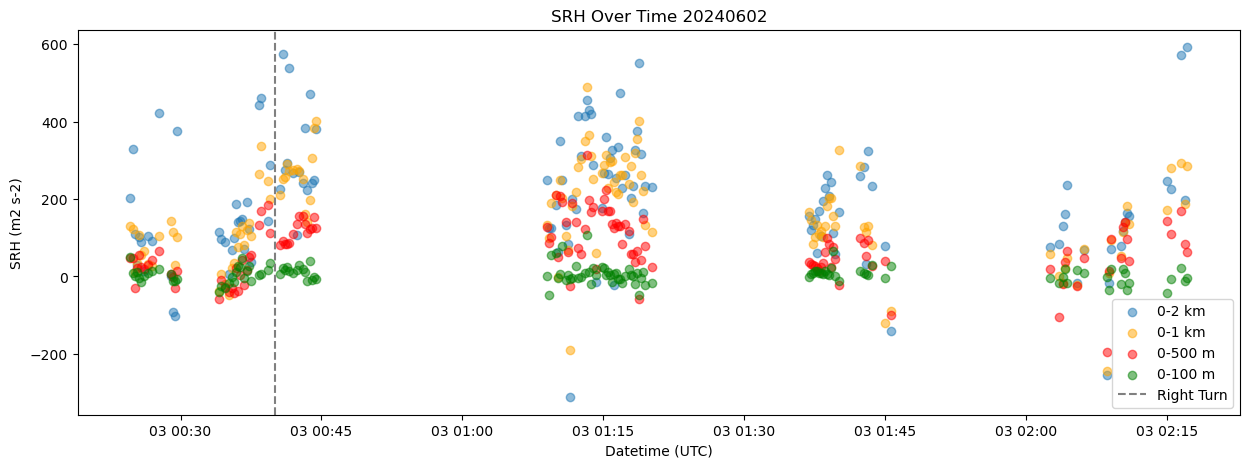

In [69]:
rt_time = pd.Timestamp('2024-06-03 00:40:00')
plot_stuff(test_case7, '20240602', rt_time)

In [70]:
test_case8 = right_turn_time('20220523', '2022-05-23 23:40:00')
test_case8['Right Turn'].value_counts()

Right Turn
before    90
after     50
Name: count, dtype: int64

In [87]:
pd.crosstab(test_case8['Right Turn'], test_case8['NF or FF'])

NF or FF,ff,nf
Right Turn,,
after,16,34
before,48,42


In [104]:
bef_u, bef_v, af_u, af_v = before_after_uv_avg(test_case8)
before_avg_u_nf, before_avg_v_nf, before_avg_u_ff, before_avg_v_ff, after_avg_u_nf, after_avg_v_nf, after_avg_u_ff, after_avg_v_ff = bef_af_nf_ff_avg(test_case8)
case8_srh2k, case8_srh1k, case8_srh5, case8_srh1 = calc_srh_for_heights(test_case8)

In [72]:
name_columns(test_case8, 'SRH', case8_srh2k, case8_srh1k, case8_srh5, case8_srh1)

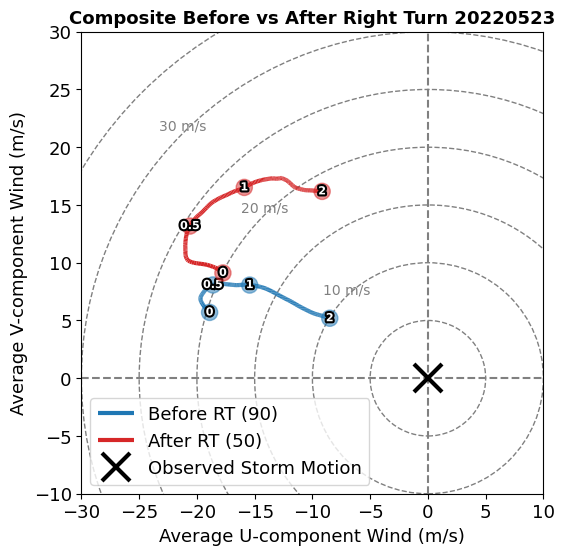

In [73]:
d = '20220523'
heights = np.arange(50, 2010, 10)

hodo_plot([bef_u, af_u], [bef_v, af_v], heights, 25, f'Composite Before vs After Right Turn {d}', ['tab:blue', 'tab:red'], [f'Before RT ({test_case8['Right Turn'].value_counts()[0]})', 
                                                                                                                            f'After RT ({test_case8['Right Turn'].value_counts()[1]})'],
          10, 30, 'lower left', 6,6)

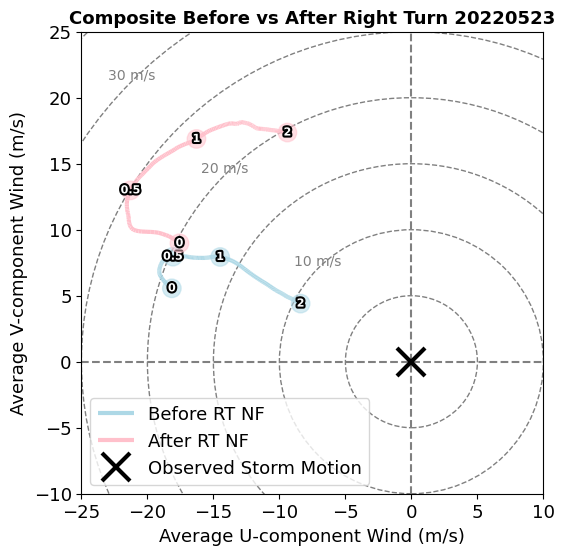

In [108]:
d = '20220523'
heights = np.arange(50, 2010, 10)

hodo_plot([before_avg_u_nf, after_avg_u_nf], [before_avg_v_nf, after_avg_v_nf], heights, 25, 
          f'Composite Before vs After Right Turn {d}', ['lightblue', 'pink'], [f'Before RT NF', 'After RT NF'
                                                                                                               ],
          10, 25, 'lower left', 6,6)

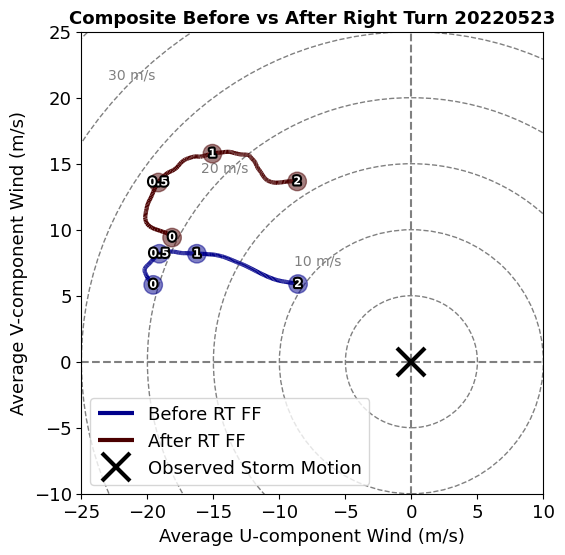

In [109]:
d = '20220523'
heights = np.arange(50, 2010, 10)

hodo_plot([before_avg_u_ff, after_avg_u_ff], [before_avg_v_ff, after_avg_v_ff], heights, 25, 
          f'Composite Before vs After Right Turn {d}', ['darkblue', very_dark_red], ['Before RT FF', 'After RT FF'
                                                                                                               ],
          10, 25, 'lower left', 6,6)

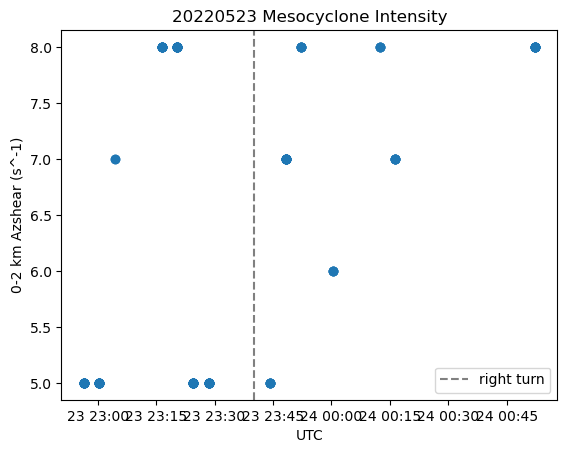

In [151]:
date = '20220523'
date_select = meso_azshear_df[meso_azshear_df['Date'] == date]
rt_time = pd.Timestamp('2022-05-23 23:40:00')
plt.figure()
plt.scatter(date_select['Time'], date_select['Meso_Max'])
plt.title(f'{date} Mesocyclone Intensity')
plt.axvline(rt_time, linestyle='--', color='gray', label='right turn')
plt.legend()
plt.xlabel('UTC')
plt.ylabel('0-2 km Azshear (s^-1)')
plt.show()

In [74]:
test_case9 = right_turn_time('20230613', '2023-06-13 19:30:00')
test_case9['Right Turn'].value_counts()

Right Turn
after    20
Name: count, dtype: int64

In [88]:
pd.crosstab(test_case9['Right Turn'], test_case9['NF or FF'])

NF or FF,nf
Right Turn,
after,20


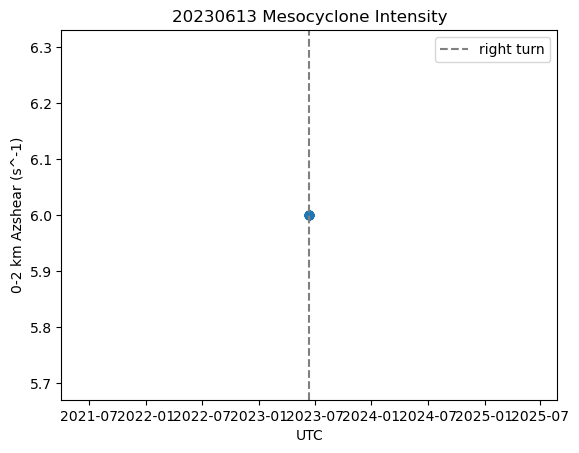

In [152]:
date = '20230613'
date_select = meso_azshear_df[meso_azshear_df['Date'] == date]
rt_time = pd.Timestamp('2023-06-13 19:30:00')
plt.figure()
plt.scatter(date_select['Time'], date_select['Meso_Max'])
plt.title(f'{date} Mesocyclone Intensity')
plt.axvline(rt_time, linestyle='--', color='gray', label='right turn')
plt.legend()
plt.xlabel('UTC')
plt.ylabel('0-2 km Azshear (s^-1)')
plt.show()